# Bài 03 — Kỹ thuật lập trình Python với Numpy

Notebook giải lần lượt toàn bộ yêu cầu trong `my_lesson3.html`. Bài tập tập trung vào Numpy, Matplotlib và mô phỏng Monte Carlo; chưa có bước huấn luyện mô hình Deep Learning.

**Quy ước đã làm rõ:**
- Mảng `a` gồm 10 số nguyên trong `[100, 200)`, phù hợp kết quả minh họa của đề.
- Câu 1.4(a) dùng đúng 100 phần tử như phần mô tả; có thể đổi bằng `N_UNIFORM`.
- Câu 1.4(b) dùng 100 điểm.
- Monte Carlo sinh điểm trong `[-1, 1] × [-1, 1]`; đoạn `[-1, -1]` trong đề là lỗi đánh máy.
- Dùng seed cố định để có thể chạy lại và kiểm chứng kết quả.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np

# Cấu hình chung: seed giúp kết quả ngẫu nhiên có thể tái lập.
SEED = 42
rng = np.random.default_rng(SEED)

# Tạo thư mục kết quả tương đối so với nơi Jupyter đang chạy.
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def kiem_tra_shape(array, expected_shape, ten_bien):
    """Báo lỗi rõ ràng nếu mảng không có kích thước mong đợi."""
    if array.shape != expected_shape:
        raise ValueError(
            f'{ten_bien} có shape {array.shape}, cần phải là {expected_shape}'
        )

print(f'Numpy: {np.__version__}')
print(f'Thư mục lưu biểu đồ: {OUTPUT_DIR.resolve()}')

Numpy: 2.4.6
Thư mục lưu biểu đồ: C:\Users\TGC\OneDrive\Documents\ChatGPT\python-deep-learning\bai03\outputs


## Bài 1. Tính toán trên dãy số

### 1.1. Tạo dãy số `a` có 10 phần tử

In [2]:
N = 10
a = rng.integers(low=100, high=200, size=N)

if a.ndim != 1 or len(a) != N:
    raise ValueError('Mảng a phải là mảng một chiều gồm đúng 10 phần tử.')

print('Dãy số a:', a)

Dãy số a: [108 177 165 143 143 185 108 169 120 109]


### 1.2. Các phép tính cơ bản

Phương sai trong đề dùng mẫu số `N-1`, tức **phương sai mẫu**. Độ lệch chuẩn là căn bậc hai của phương sai. Đây là các phép tính thống kê, chưa liên quan đến loss function của mô hình học sâu.

In [3]:
a_binh_phuong = a ** 2
so_phan_tu = a.size
gia_tri_lon_nhat = np.max(a)
gia_tri_nho_nhat = np.min(a)
trung_binh = np.mean(a)

if so_phan_tu < 2:
    raise ValueError('Cần ít nhất 2 phần tử để tính phương sai mẫu với N-1.')

# Tính đúng theo công thức đề bài, không gọi tắt np.var ở bước chính.
phuong_sai_mau = np.sum((a - trung_binh) ** 2) / (so_phan_tu - 1)
do_lech_chuan_mau = np.sqrt(phuong_sai_mau)

# Đối chiếu với hàm thư viện: ddof=1 cũng dùng mẫu số N-1.
assert np.isclose(phuong_sai_mau, np.var(a, ddof=1))
assert np.isclose(do_lech_chuan_mau, np.std(a, ddof=1))

print('a) Bình phương a:', a_binh_phuong)
print('b) Số phần tử:', so_phan_tu)
print(f'c) Max={gia_tri_lon_nhat}, min={gia_tri_nho_nhat}, trung bình={trung_binh:.2f}')
print(f'd) Phương sai mẫu={phuong_sai_mau:.2f}, độ lệch chuẩn mẫu={do_lech_chuan_mau:.2f}')

a) Bình phương a: [11664 31329 27225 20449 20449 34225 11664 28561 14400 11881]
b) Số phần tử: 10
c) Max=185, min=108, trung bình=142.70
d) Phương sai mẫu=912.68, độ lệch chuẩn mẫu=30.21


### 1.3. Các toán tử trên hai dãy số

“Vị trí lẻ” được hiểu theo chỉ số Python bắt đầu từ 0: `1, 3, 5, 7, 9`, đúng với output minh họa của đề.

In [4]:
x = np.arange(1, 11)
kiem_tra_shape(x, (10,), 'x')

def tach_chan_le(day_so):
    """Trả về mask và các phần tử chẵn/lẻ của một mảng số nguyên."""
    day_so = np.asarray(day_so)
    if day_so.ndim != 1:
        raise ValueError('Dữ liệu đầu vào phải là mảng một chiều.')
    mask_chan = day_so % 2 == 0
    mask_le = ~mask_chan
    return mask_chan, day_so[mask_chan], mask_le, day_so[mask_le]

a_mask_chan, a_chan, a_mask_le, a_le_gia_tri = tach_chan_le(a)
x_mask_chan, x_chan, x_mask_le, x_le_gia_tri = tach_chan_le(x)

chi_so_le = np.arange(1, len(a), 2)
a_tai_chi_so_le = a[chi_so_le]
x_tai_chi_so_le = x[chi_so_le]
hieu_tai_chi_so_le = a_tai_chi_so_le - x_tai_chi_so_le
khoang_cach_chi_so_le = np.sqrt(np.sum(hieu_tai_chi_so_le ** 2))

# Broadcasting: (10, 1) - (10,) tạo ma trận 10×10 chứa mọi hiệu a_i-x_j.
ma_tran_khoang_cach = np.abs(a[:, np.newaxis] - x)
khoang_cach_nho_nhat = np.min(ma_tran_khoang_cach)
vi_tri_min = np.unravel_index(np.argmin(ma_tran_khoang_cach), ma_tran_khoang_cach.shape)

print('a) Dãy x:', x)
print(f'b) a chẵn: {a_chan} — {a_chan.size} phần tử')
print(f'   a lẻ:   {a_le_gia_tri} — {a_le_gia_tri.size} phần tử')
print(f'   x chẵn: {x_chan} — {x_chan.size} phần tử')
print(f'   x lẻ:   {x_le_gia_tri} — {x_le_gia_tri.size} phần tử')
print(f'c) Chỉ số lẻ: {chi_so_le}')
print(f'   Hiệu tại chỉ số lẻ: {hieu_tai_chi_so_le}')
print(f'   Khoảng cách Euclid: {khoang_cach_chi_so_le:.2f}')
print(f'd) Khoảng cách nhỏ nhất: {khoang_cach_nho_nhat}')
print(f'   Cặp gần nhất: a[{vi_tri_min[0]}]={a[vi_tri_min[0]]}, x[{vi_tri_min[1]}]={x[vi_tri_min[1]]}')

a) Dãy x: [ 1  2  3  4  5  6  7  8  9 10]
b) a chẵn: [108 108 120] — 3 phần tử
   a lẻ:   [177 165 143 143 185 169 109] — 7 phần tử
   x chẵn: [ 2  4  6  8 10] — 5 phần tử
   x lẻ:   [1 3 5 7 9] — 5 phần tử
c) Chỉ số lẻ: [1 3 5 7 9]
   Hiệu tại chỉ số lẻ: [175 139 179 161  99]
   Khoảng cách Euclid: 343.09
d) Khoảng cách nhỏ nhất: 98
   Cặp gần nhất: a[0]=108, x[9]=10


### 1.4(a). Phân bố đều rời rạc trong `[1, 10]`

Theo câu chữ của đề, ta sinh 100 phần tử. Vì cỡ mẫu nhỏ, chiều cao các cột không nhất thiết bằng nhau.

Giá trị: [ 1  2  3  4  5  6  7  8  9 10]
Số lần xuất hiện: [ 7 10  5  9 14  7 10 18 13  7]


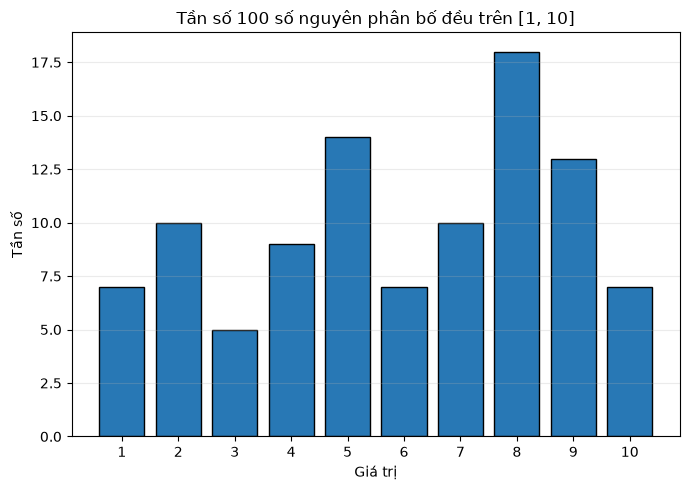

Đã lưu: outputs\bai1_4a_tan_so_phan_bo_deu.png


In [5]:
N_UNIFORM = 100
day_phan_bo_deu = rng.integers(1, 11, size=N_UNIFORM)
gia_tri_deu, tan_so_deu = np.unique(day_phan_bo_deu, return_counts=True)
assert tan_so_deu.sum() == N_UNIFORM

print('Giá trị:', gia_tri_deu)
print('Số lần xuất hiện:', tan_so_deu)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(gia_tri_deu, tan_so_deu, color='#2878B5', edgecolor='black')
ax.set(title='Tần số 100 số nguyên phân bố đều trên [1, 10]', xlabel='Giá trị', ylabel='Tần số')
ax.set_xticks(np.arange(1, 11))
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
duong_dan_4a = OUTPUT_DIR / 'bai1_4a_tan_so_phan_bo_deu.png'
fig.savefig(duong_dan_4a, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Đã lưu:', duong_dan_4a)

### 1.4(b). Các điểm nằm trên hàm mật độ chuẩn `N(μ=1, σ²=1)`

Ta sinh ngẫu nhiên hoành độ trong `[μ-5σ, μ+5σ]`, sau đó tính tung độ bằng công thức mật độ chuẩn của đề.

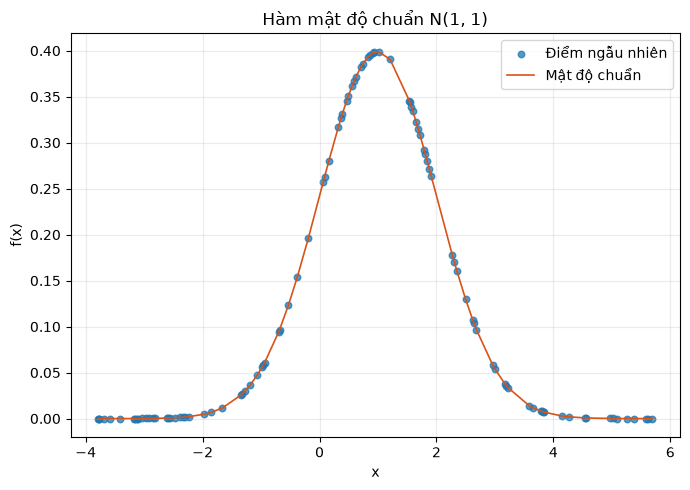

x: -4.0 ≤ min=-3.784 ≤ max=5.692 ≤ 6.0
Đã lưu: outputs\bai1_4b_ham_mat_do_chuan.png


In [6]:
MU = 1.0
SIGMA = 1.0
N_DIEM = 100
x_min, x_max = MU - 5 * SIGMA, MU + 5 * SIGMA
x_pdf = rng.uniform(x_min, x_max, size=N_DIEM)
y_pdf = (1 / (SIGMA * np.sqrt(2 * np.pi))) * np.exp(-((x_pdf - MU) ** 2) / (2 * SIGMA ** 2))

if not np.all((x_pdf >= x_min) & (x_pdf <= x_max)):
    raise ValueError('Có giá trị x nằm ngoài miền yêu cầu.')

thu_tu = np.argsort(x_pdf)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x_pdf, y_pdf, s=22, alpha=0.75, label='Điểm ngẫu nhiên')
ax.plot(x_pdf[thu_tu], y_pdf[thu_tu], color='#D95319', linewidth=1.2, label='Mật độ chuẩn')
ax.set(title='Hàm mật độ chuẩn N(1, 1)', xlabel='x', ylabel='f(x)')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
duong_dan_4b = OUTPUT_DIR / 'bai1_4b_ham_mat_do_chuan.png'
fig.savefig(duong_dan_4b, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'x: {x_min} ≤ min={x_pdf.min():.3f} ≤ max={x_pdf.max():.3f} ≤ {x_max}')
print('Đã lưu:', duong_dan_4b)

### 1.4(c). Histogram của 100.000 mẫu chuẩn `N(1,1)`

`density=True` chuẩn hóa histogram thành mật độ xác suất. Đường lý thuyết giúp đối chiếu hình dạng phân phối.

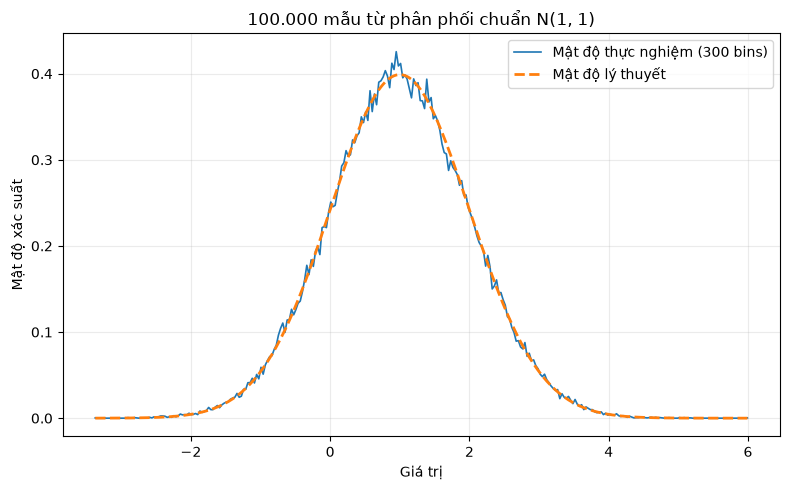

Số mẫu=100,000, min=-3.3891, max=6.0072
Đã lưu: outputs\bai1_4c_histogram_phan_bo_chuan.png


In [7]:
N_NORMAL = 100_000
mau_chuan = MU + rng.standard_normal(N_NORMAL) * SIGMA
mat_do, bien_bin = np.histogram(mau_chuan, bins=300, density=True)
tam_bin = (bien_bin[:-1] + bien_bin[1:]) / 2
mat_do_ly_thuyet = (1 / (SIGMA * np.sqrt(2 * np.pi))) * np.exp(-((tam_bin - MU) ** 2) / (2 * SIGMA ** 2))

assert len(mau_chuan) == N_NORMAL
assert mat_do.shape == tam_bin.shape

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tam_bin, mat_do, linewidth=1.2, label='Mật độ thực nghiệm (300 bins)')
ax.plot(tam_bin, mat_do_ly_thuyet, '--', linewidth=2, label='Mật độ lý thuyết')
ax.set(title='100.000 mẫu từ phân phối chuẩn N(1, 1)', xlabel='Giá trị', ylabel='Mật độ xác suất')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
duong_dan_4c = OUTPUT_DIR / 'bai1_4c_histogram_phan_bo_chuan.png'
fig.savefig(duong_dan_4c, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Số mẫu={len(mau_chuan):,}, min={mau_chuan.min():.4f}, max={mau_chuan.max():.4f}')
print('Đã lưu:', duong_dan_4c)

## Bài 2. Tính toán trên ma trận

### 2.1–2.2. Tạo ma trận `6×4` và thực hiện các phép truy xuất

Đề và output mẫu dùng chỉ số Python bắt đầu từ 0. Vì vậy “dòng 2, cột 3” được lấy bằng `a_matrix[2, 3]`.

In [8]:
a_matrix = rng.integers(100, 200, size=(6, 4))
kiem_tra_shape(a_matrix, (6, 4), 'a_matrix')

a_chuyen_vi = a_matrix.T
phan_tu_2_3 = a_matrix[2, 3]
dong_dau = a_matrix[0, :]
dong_cuoi = a_matrix[-1, :]
dong_2 = a_matrix[2, :]
cot_ke_cuoi = a_matrix[:, -2]
cot_dau = a_matrix[:, 0]
dao_gia_tri_tung_cot = a_matrix[::-1, :]
tong_theo_dong = np.sum(a_matrix, axis=1)
trung_binh_theo_cot = np.mean(a_matrix, axis=0)

print('Ma trận a:')
print(a_matrix)
print()
print('a) Chuyển vị:')
print(a_chuyen_vi)
print()
print('b) Phần tử tại chỉ số dòng 2, cột 3:', phan_tu_2_3)
print()
print('c) Dòng đầu:', dong_dau)
print('   Dòng cuối:', dong_cuoi)
print('   Dòng chỉ số 2:', dong_2)
print()
print('d) Cột kế cuối:', cot_ke_cuoi)
print('   Cột đầu:', cot_dau)
print()
print('e) Đảo giá trị trên từng cột:')
print(dao_gia_tri_tung_cot)
print()
print('f) Tổng từng dòng:', tong_theo_dong)
print('   Trung bình từng cột:', trung_binh_theo_cot)

Ma trận a:
[[173 184 106 153]
 [112 157 148 192]
 [105 140 163 173]
 [154 186 118 159]
 [146 160 157 149]
 [102 109 187 128]]

a) Chuyển vị:
[[173 112 105 154 146 102]
 [184 157 140 186 160 109]
 [106 148 163 118 157 187]
 [153 192 173 159 149 128]]

b) Phần tử tại chỉ số dòng 2, cột 3: 173

c) Dòng đầu: [173 184 106 153]
   Dòng cuối: [102 109 187 128]
   Dòng chỉ số 2: [105 140 163 173]

d) Cột kế cuối: [106 148 163 118 157 187]
   Cột đầu: [173 112 105 154 146 102]

e) Đảo giá trị trên từng cột:
[[102 109 187 128]
 [146 160 157 149]
 [154 186 118 159]
 [105 140 163 173]
 [112 157 148 192]
 [173 184 106 153]]

f) Tổng từng dòng: [616 609 581 617 612 526]
   Trung bình từng cột: [132.  156.  146.5 159. ]


### 2.3. Các toán tử trên hai ma trận

`A * B` là nhân từng phần tử, còn `A @ X` là phép nhân ma trận. Hai phép toán này cần được phân biệt rõ khi trình bày.

In [9]:
A = rng.integers(1, 6, size=(4, 3))
B = rng.integers(1, 6, size=(4, 3))
X = rng.integers(1, 6, size=(3, 4))
kiem_tra_shape(A, (4, 3), 'A')
kiem_tra_shape(B, (4, 3), 'B')
kiem_tra_shape(X, (3, 4), 'X')

AB_cong = A + B
AB_tru = A - B
AB_nhan_tung_phan_tu = A * B
Y = A @ X
kiem_tra_shape(Y, (4, 4), 'Y')

print('A =')
print(A)
print('B =')
print(B)
print('X =')
print(X)
print()
print('A + B =')
print(AB_cong)
print('A - B =')
print(AB_tru)
print('A * B (từng phần tử) =')
print(AB_nhan_tung_phan_tu)
print(f'A @ X: {A.shape} @ {X.shape} -> {Y.shape}')
print(Y)

A =
[[3 2 2]
 [2 3 2]
 [5 5 2]
 [3 5 5]]
B =
[[2 3 4]
 [4 3 3]
 [1 5 4]
 [1 1 2]]
X =
[[5 4 5 4]
 [4 1 1 3]
 [3 2 2 5]]

A + B =
[[ 5  5  6]
 [ 6  6  5]
 [ 6 10  6]
 [ 4  6  7]]
A - B =
[[ 1 -1 -2]
 [-2  0 -1]
 [ 4  0 -2]
 [ 2  4  3]]
A * B (từng phần tử) =
[[ 6  6  8]
 [ 8  9  6]
 [ 5 25  8]
 [ 3  5 10]]
A @ X: (4, 3) @ (3, 4) -> (4, 4)
[[29 18 21 28]
 [28 15 17 27]
 [51 29 34 45]
 [50 27 30 52]]


### 2.4. Giải hệ phương trình tuyến tính

Với hệ vuông `Ax=y`, `np.linalg.solve` ổn định và phù hợp hơn việc tự tính `A⁻¹ @ y`. Chuẩn phần dư `||Ax-y||₂` gần 0 xác nhận nghiệm.

In [10]:
A_he = np.array([[4, 3, -5], [-2, -4, 5], [8, 8, 0]], dtype=float)
y_he = np.array([2, 5, -3], dtype=float)

if A_he.shape[0] != A_he.shape[1] or A_he.shape[0] != y_he.size:
    raise ValueError('Hệ phương trình phải có ma trận vuông và vector y tương thích.')
if np.isclose(np.linalg.det(A_he), 0.0):
    raise np.linalg.LinAlgError('Ma trận hệ số suy biến, hệ không có nghiệm duy nhất.')

nghiem = np.linalg.solve(A_he, y_he)
y_kiem_tra = A_he @ nghiem
chuan_phan_du = np.linalg.norm(y_kiem_tra - y_he, ord=2)

print('Ma trận hệ số A:')
print(A_he)
print('Vector y:', y_he)
print('Nghiệm x:', nghiem)
print('Kiểm tra Ax:', y_kiem_tra)
print(f'||Ax-y||₂ = {chuan_phan_du:.12f}')
assert chuan_phan_du < 1e-10

Ma trận hệ số A:
[[ 4.  3. -5.]
 [-2. -4.  5.]
 [ 8.  8.  0.]]
Vector y: [ 2.  5. -3.]
Nghiệm x: [ 2.20833333 -2.58333333 -0.18333333]
Kiểm tra Ax: [ 2.  5. -3.]
||Ax-y||₂ = 0.000000000000


## Bài 3. Xấp xỉ số π bằng phương pháp Monte Carlo

Mỗi điểm được sinh đều trong hình vuông `[-1,1]×[-1,1]`. Điểm nằm trong đường tròn đơn vị khi `x²+y²≤1`. Tỉ lệ điểm trong đường tròn xấp xỉ `π/4`, do đó `π ≈ 4N_C/N`.

Đây là mô phỏng xác suất: khi `N` tăng, sai số thường giảm nhưng không bắt buộc giảm đơn điệu trong mọi lần chạy.

In [11]:
def calc_pi_monte_carlo(n, random_generator):
    """Xấp xỉ π và trả thêm dữ liệu điểm để kiểm tra/vẽ hình."""
    if not isinstance(n, (int, np.integer)) or n <= 0:
        raise ValueError('n phải là số nguyên dương.')
    if not isinstance(random_generator, np.random.Generator):
        raise TypeError('random_generator phải là np.random.Generator.')

    diem = random_generator.uniform(-1.0, 1.0, size=(n, 2))
    binh_phuong_ban_kinh = np.sum(diem ** 2, axis=1)
    nam_trong = binh_phuong_ban_kinh <= 1.0
    so_diem_trong = np.count_nonzero(nam_trong)
    pi_xap_xi = 4.0 * so_diem_trong / n
    return pi_xap_xi, diem, nam_trong

cac_N = [100, 10_000, 1_000_000]
ket_qua_pi = []
for i, n in enumerate(cac_N):
    # Seed riêng giúp mỗi thí nghiệm độc lập nhưng vẫn tái lập được.
    pi_xap_xi, _, _ = calc_pi_monte_carlo(n, np.random.default_rng(SEED + i))
    sai_so_co_dau = pi_xap_xi - math.pi
    sai_so_tuyet_doi = abs(sai_so_co_dau)
    ket_qua_pi.append((n, pi_xap_xi, sai_so_co_dau, sai_so_tuyet_doi))

print(f'{"N":>12} | {"π xấp xỉ":>12} | {"Sai số có dấu":>15} | {"Sai số tuyệt đối":>17}')
print('-' * 68)
for n, pi_xap_xi, sai_so_co_dau, sai_so_tuyet_doi in ket_qua_pi:
    print(f'{n:12,d} | {pi_xap_xi:12.8f} | {sai_so_co_dau:15.8f} | {sai_so_tuyet_doi:17.8f}')

           N |     π xấp xỉ |   Sai số có dấu |  Sai số tuyệt đối
--------------------------------------------------------------------
         100 |   3.28000000 |      0.13840735 |        0.13840735
      10,000 |   3.16320000 |      0.02160735 |        0.02160735
   1,000,000 |   3.14074800 |     -0.00084465 |        0.00084465


### Minh họa Monte Carlo và sai số

Hình thứ nhất phân biệt các điểm nằm trong/ngoài đường tròn. Hình thứ hai dùng thang logarit để so sánh sai số tuyệt đối theo `N`.

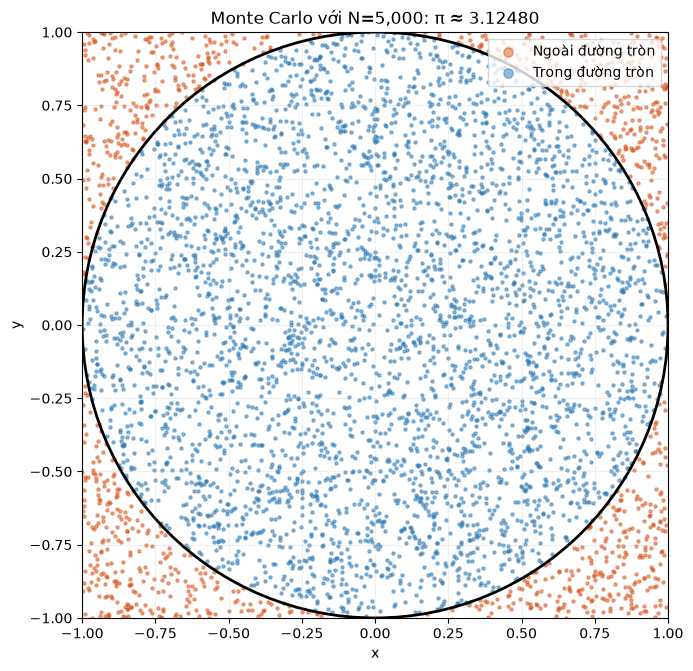

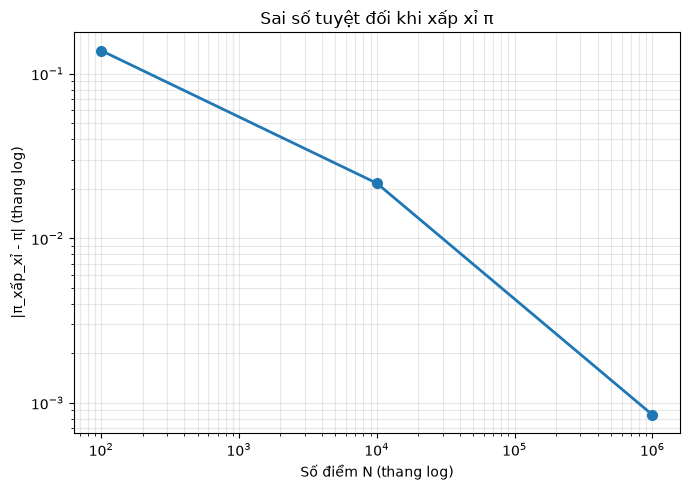

Đã lưu: outputs\bai3_monte_carlo_points.png
Đã lưu: outputs\bai3_sai_so_pi.png


In [12]:
N_VE = 5_000
pi_ve, diem_ve, mask_trong_ve = calc_pi_monte_carlo(N_VE, np.random.default_rng(SEED + 100))

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(diem_ve[~mask_trong_ve, 0], diem_ve[~mask_trong_ve, 1], s=5, alpha=0.5, color='#D95319', label='Ngoài đường tròn')
ax.scatter(diem_ve[mask_trong_ve, 0], diem_ve[mask_trong_ve, 1], s=5, alpha=0.5, color='#2878B5', label='Trong đường tròn')
duong_tron = plt.Circle((0, 0), 1, fill=False, color='black', linewidth=2)
ax.add_patch(duong_tron)
ax.set(xlim=(-1, 1), ylim=(-1, 1), xlabel='x', ylabel='y', title=f'Monte Carlo với N={N_VE:,}: π ≈ {pi_ve:.5f}')
ax.set_aspect('equal', adjustable='box')
ax.legend(markerscale=3, loc='upper right')
ax.grid(alpha=0.2)
fig.tight_layout()
duong_dan_pi_points = OUTPUT_DIR / 'bai3_monte_carlo_points.png'
fig.savefig(duong_dan_pi_points, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

n_values = np.array([row[0] for row in ket_qua_pi])
abs_errors = np.array([row[3] for row in ket_qua_pi])
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(n_values, abs_errors, 'o-', linewidth=2, markersize=7)
ax.set(title='Sai số tuyệt đối khi xấp xỉ π', xlabel='Số điểm N (thang log)', ylabel='|π_xấp_xỉ - π| (thang log)')
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
duong_dan_pi_error = OUTPUT_DIR / 'bai3_sai_so_pi.png'
fig.savefig(duong_dan_pi_error, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

print('Đã lưu:', duong_dan_pi_points)
print('Đã lưu:', duong_dan_pi_error)

## Kiểm tra cuối bài và lưu ý khi bảo vệ

- Numpy **broadcasting** tạo mọi cặp hiệu mà không cần hai vòng lặp Python.
- `axis=1` gộp theo từng dòng; `axis=0` gộp theo từng cột.
- `*` nhân từng phần tử, còn `@` nhân ma trận.
- Phương sai mẫu dùng `N-1`; nếu dùng `np.var`, phải đặt `ddof=1`.
- Monte Carlo cho kết quả ngẫu nhiên; tăng `N` chỉ làm sai số giảm theo xu hướng. Seed được dùng để tái lập bài demo.

In [13]:
cac_file_can_co = [
    duong_dan_4a,
    duong_dan_4b,
    duong_dan_4c,
    duong_dan_pi_points,
    duong_dan_pi_error,
]

assert a.shape == (10,)
assert x.shape == (10,)
assert a_chan.size + a_le_gia_tri.size == a.size
assert x_chan.size + x_le_gia_tri.size == x.size
assert a_matrix.shape == (6, 4)
assert Y.shape == (4, 4)
assert chuan_phan_du < 1e-10
assert all(path.exists() and path.stat().st_size > 0 for path in cac_file_can_co)
assert len(ket_qua_pi) == 3

print('TẤT CẢ KIỂM TRA ĐỀU ĐẠT')
for path in cac_file_can_co:
    print(f'  ✓ {path} ({path.stat().st_size:,} bytes)')

TẤT CẢ KIỂM TRA ĐỀU ĐẠT
  ✓ outputs\bai1_4a_tan_so_phan_bo_deu.png (29,938 bytes)
  ✓ outputs\bai1_4b_ham_mat_do_chuan.png (68,998 bytes)
  ✓ outputs\bai1_4c_histogram_phan_bo_chuan.png (67,708 bytes)
  ✓ outputs\bai3_monte_carlo_points.png (299,869 bytes)
  ✓ outputs\bai3_sai_so_pi.png (53,950 bytes)
